# Gratis Fiyat Analizi — Özellik Mühendisliği ve Kümeleme

**Notebook:** 03 — Özellik Mühendisliği ve K-Means Kümeleme  
**Proje:** Gratis'te Fiyat Davranışı Analizi: Tüketici için Veri Odaklı Alışveriş Rehberi

Bu notebook'ta temizlenmiş ürün-gün seviyesindeki veri, ürün bazlı bir analiz tablosuna dönüştürülür.

## Amaç

Bu aşamada amaç, her ürün için fiyat ve indirim davranışını özetleyen değişkenler üretmek ve ürünleri benzer davranış profillerine göre kümelere ayırmaktır.

## Yapılacak İşlemler

1. Temiz veri seti okunur.
2. Her ürün için ürün bazlı özellikler oluşturulur.
3. Fiyat, indirim, kampanya ve popülerlik değişkenleri hesaplanır.
4. Kümeleme için kullanılacak sayısal değişkenler seçilir.
5. Değişkenler standartlaştırılır.
6. K-Means algoritması uygulanır.
7. Uygun küme sayısı Elbow ve Silhouette yöntemleriyle değerlendirilir.
8. PCA ile kümeler iki boyutta görselleştirilir.
9. Kümeler tüketici açısından yorumlanır.

## Çıktılar

Bu notebook sonunda aşağıdaki dosyalar oluşturulacaktır:

- `../data/processed/urun_ozellikleri.csv`
- `../data/processed/urun_kumeleri.csv`

In [4]:
# === KÜTÜPHANELER ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Makine öğrenmesi
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

# === GÖRSEL AYARLARI ===

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Renkler
GRATIS_PEMBE = "#E91E63"
GRATIS_LACIVERT = "#1A237E"
GRATIS_GRI = "#90A4AE"
ACCENT = "#FF9800"

# === VERİYİ YÜKLE ===

PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "gratis_clean.csv"

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["tarih", "kayit_zamani", "snapshot_gun"],
    encoding="utf-8-sig"
)

print("Veri yüklendi ✓")
print(f"Satır sayısı: {len(df):,}")
print(f"Ürün sayısı: {df['urun_id'].nunique():,}")
print(f"Kategori sayısı: {df['kategori'].nunique()}")
print(f"Marka sayısı: {df['marka'].nunique():,}")
print(f"Tarih aralığı: {df['snapshot_gun'].min().date()} → {df['snapshot_gun'].max().date()}")

display(df.head(3))

Veri yüklendi ✓
Satır sayısı: 118,812
Ürün sayısı: 10,628
Kategori sayısı: 14
Marka sayısı: 422
Tarih aralığı: 2026-04-04 → 2026-05-06


,urun_id,isim,marka,kategori,fiyat,eski_fiyat,indirim_yuzde,kampanya,yorum_sayisi,begeni,url,tarih,kayit_zamani,snapshot_gun,begeni_sayi,indirimde_mi
0,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,180.0,451.0,60.1,250 TL ve Üzeri Alışverişe,10,6B,https://www.gratis.com/set-boyalar/palette-del...,2026-04-04 19:09:00,2026-04-04 19:28:27.007455,2026-04-04,6000.0,True
1,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,359.0,451.0,20.4,Kampanya Yok,10,6B,https://www.gratis.com/set-boyalar/palette-del...,2026-04-05 23:33:00,2026-04-05 23:45:32.052118,2026-04-05,6000.0,True
2,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,359.0,451.0,20.4,Kampanya Yok,10,6B,https://www.gratis.com/set-boyalar/palette-del...,2026-04-06 22:39:00,2026-04-06 23:02:24.419605,2026-04-06,6000.0,True


---

## 1) Ürün Bazlı Özellik Mühendisliği

Temiz veri seti ürün-gün seviyesindedir. Yani aynı ürün, farklı günlerde farklı fiyat ve indirim değerleriyle gözlemlenmiştir.

Kümeleme yapabilmek için her ürünü tek satırla temsil eden bir özellik tablosu oluşturmamız gerekir.

Bu bölümde her ürün için aşağıdaki değişken grupları hesaplanacaktır:

- **Fiyat özellikleri:** Ortalama fiyat, medyan fiyat, minimum/maksimum fiyat, fiyat oynaklığı
- **İndirim özellikleri:** Ortalama indirim, maksimum indirim, indirimli gün oranı
- **Kampanya özellikleri:** Kampanyalı gün oranı, farklı kampanya sayısı
- **Popülerlik özellikleri:** Yorum sayısı, beğeni sayısı
- **Gözlem özellikleri:** Ürünün kaç farklı gün gözlemlendiği

In [5]:
# === ÜRÜN BAZLI ÖZELLİK TABLOSU OLUŞTURMA ===

# Önce veriyi ürün ve tarihe göre sırala
df_sorted = df.sort_values(["urun_id", "snapshot_gun"]).copy()

# İlk ve son fiyatları hesaplamak için yardımcı tablolar
ilk_fiyat = df_sorted.groupby("urun_id")["fiyat"].first()
son_fiyat = df_sorted.groupby("urun_id")["fiyat"].last()

# Ürün bazlı ana özellik tablosu
urun_ozellikleri = df_sorted.groupby("urun_id").agg(
    # Kimlik bilgileri
    isim=("isim", "first"),
    marka=("marka", "first"),
    kategori=("kategori", "first"),
    
    # Gözlem sayısı
    gozlem_sayisi=("snapshot_gun", "nunique"),
    
    # Fiyat özellikleri
    ortalama_fiyat=("fiyat", "mean"),
    medyan_fiyat=("fiyat", "median"),
    min_fiyat=("fiyat", "min"),
    max_fiyat=("fiyat", "max"),
    fiyat_std=("fiyat", "std"),
    
    # İndirim özellikleri
    ortalama_indirim=("indirim_yuzde", "mean"),
    medyan_indirim=("indirim_yuzde", "median"),
    max_indirim=("indirim_yuzde", "max"),
    indirim_std=("indirim_yuzde", "std"),
    indirimli_gun_orani=("indirimde_mi", "mean"),
    
    # Kampanya özellikleri
    kampanyali_gun_orani=("kampanya", lambda x: (x != "Kampanya Yok").mean()),
    farkli_kampanya_sayisi=("kampanya", lambda x: x[x != "Kampanya Yok"].nunique()),
    
    # Popülerlik özellikleri
    yorum_sayisi=("yorum_sayisi", "max"),
    begeni_sayi=("begeni_sayi", "max")
).reset_index()

# İlk ve son fiyatları ekle
urun_ozellikleri["ilk_fiyat"] = urun_ozellikleri["urun_id"].map(ilk_fiyat)
urun_ozellikleri["son_fiyat"] = urun_ozellikleri["urun_id"].map(son_fiyat)

# Türetilmiş fiyat özellikleri
urun_ozellikleri["fiyat_araligi"] = urun_ozellikleri["max_fiyat"] - urun_ozellikleri["min_fiyat"]

urun_ozellikleri["fiyat_araligi_orani"] = (
    urun_ozellikleri["fiyat_araligi"] / urun_ozellikleri["medyan_fiyat"].replace(0, np.nan)
)

urun_ozellikleri["fiyat_degisim_orani"] = (
    (urun_ozellikleri["son_fiyat"] - urun_ozellikleri["ilk_fiyat"]) 
    / urun_ozellikleri["ilk_fiyat"].replace(0, np.nan)
)

# Fiyat standart sapması boşsa 0 kabul edilir
# Çünkü bazı ürünlerde fiyat hiç değişmemiş olabilir
urun_ozellikleri["fiyat_std"] = urun_ozellikleri["fiyat_std"].fillna(0)
urun_ozellikleri["indirim_std"] = urun_ozellikleri["indirim_std"].fillna(0)

# Popülerlik skoru
urun_ozellikleri["populerlik_skoru"] = (
    np.log1p(urun_ozellikleri["yorum_sayisi"].fillna(0)) +
    np.log1p(urun_ozellikleri["begeni_sayi"].fillna(0))
)

# Log fiyat
# Fiyat dağılımı sağa çarpık olduğu için kümelemede log dönüşümü kullanacağız
urun_ozellikleri["log_ortalama_fiyat"] = np.log1p(urun_ozellikleri["ortalama_fiyat"])

print("Ürün bazlı özellik tablosu oluşturuldu ✓")
print(f"Satır sayısı: {len(urun_ozellikleri):,}")
print(f"Sütun sayısı: {urun_ozellikleri.shape[1]}")

display(urun_ozellikleri.head())

Ürün bazlı özellik tablosu oluşturuldu ✓
Satır sayısı: 10,628
Sütun sayısı: 26


,urun_id,isim,marka,kategori,gozlem_sayisi,ortalama_fiyat,medyan_fiyat,min_fiyat,max_fiyat,fiyat_std,...,farkli_kampanya_sayisi,yorum_sayisi,begeni_sayi,ilk_fiyat,son_fiyat,fiyat_araligi,fiyat_araligi_orani,fiyat_degisim_orani,populerlik_skoru,log_ortalama_fiyat
0,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,15,335.133333,359.0,180.0,359.0,62.983974,...,1,10,6000.0,180.0,359.0,179.0,0.498607,0.994444,11.097577,5.817508
1,10000236,Kalyon Tırnak Besleyici,Kalyon,Makyaj,10,249.550000,265.5,106.0,265.5,50.438329,...,1,79,34000.0,106.0,265.5,159.5,0.600753,1.504717,14.816172,5.523659
2,10000237,Kalyon Oje Kurutucu Sprey,Kalyon,Makyaj,10,300.950000,346.0,103.5,346.0,95.321226,...,1,28,9000.0,138.0,346.0,242.5,0.700867,1.507246,12.472387,5.710261
3,10000238,Kalyon Oje Koruyucu,Kalyon,Makyaj,6,265.500000,265.5,265.5,265.5,0.000000,...,0,19,10000.0,265.5,265.5,0.0,0.000000,0.000000,12.206173,5.585374
4,10000240,Kalyon Bakım Yağı,Kalyon,Makyaj,8,245.562500,265.5,106.0,265.5,56.391766,...,1,40,14000.0,265.5,265.5,159.5,0.600753,0.000000,13.260456,5.507616


---

## 2) Özellik Tablosu Kalite Kontrolü

Ürün bazlı özellik tablosu oluşturulduktan sonra, kümeleme aşamasına geçmeden önce eksik değerler, sonsuz değerler ve temel istatistikler kontrol edilmiştir.

K-Means gibi uzaklık temelli algoritmalar eksik değerlerden ve aşırı uç değerlerden etkilenebileceği için bu kontrol modelleme öncesinde kritik bir adımdır.

In [6]:
# === ÖZELLİK TABLOSU KALİTE KONTROLÜ ===

print("=== ÜRÜN ÖZELLİKLERİ GENEL BİLGİ ===")
print(f"Satır sayısı: {len(urun_ozellikleri):,}")
print(f"Sütun sayısı: {urun_ozellikleri.shape[1]}")
print(f"Benzersiz ürün sayısı: {urun_ozellikleri['urun_id'].nunique():,}")

print("\n=== EKSİK DEĞER SAYILARI ===")
eksik_degerler = urun_ozellikleri.isnull().sum()
print(eksik_degerler[eksik_degerler > 0])

print("\n=== SAYISAL DEĞİŞKENLERİN ÖZET İSTATİSTİKLERİ ===")
display(urun_ozellikleri.select_dtypes(include=["number"]).describe().T)

# Sonsuz değer kontrolü
numeric_cols = urun_ozellikleri.select_dtypes(include=["number"]).columns

inf_count = np.isinf(urun_ozellikleri[numeric_cols]).sum().sum()
print(f"\nSonsuz değer sayısı: {inf_count}")

# Eğer sonsuz değer varsa NaN'a çevir
urun_ozellikleri[numeric_cols] = urun_ozellikleri[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Kalan NaN değerleri kontrol et
print("\n=== SON KONTROL — EKSİK DEĞERLER ===")
print(urun_ozellikleri.isnull().sum()[urun_ozellikleri.isnull().sum() > 0])

=== ÜRÜN ÖZELLİKLERİ GENEL BİLGİ ===
Satır sayısı: 10,628
Sütun sayısı: 26
Benzersiz ürün sayısı: 10,628

=== EKSİK DEĞER SAYILARI ===
Series([], dtype: int64)

=== SAYISAL DEĞİŞKENLERİN ÖZET İSTATİSTİKLERİ ===


,count,mean,std,min,25%,50%,75%,max
urun_id,10628.0,1.046882e+07,1.435166e+06,1.000005e+07,1.020227e+07,1.021069e+07,1.021695e+07,2.900006e+07
gozlem_sayisi,10628.0,1.117915e+01,2.313382e+00,5.000000e+00,1.000000e+01,1.200000e+01,1.300000e+01,1.500000e+01
ortalama_fiyat,10628.0,3.521713e+02,8.579782e+02,6.166667e+00,1.174773e+02,2.062924e+02,3.393594e+02,1.948975e+04
medyan_fiyat,10628.0,3.731406e+02,9.144868e+02,7.000000e+00,1.245000e+02,2.170000e+02,3.590000e+02,2.292900e+04
min_fiyat,10628.0,2.472304e+02,6.389482e+02,3.000000e+00,7.550000e+01,1.395000e+02,2.300000e+02,1.559900e+04
max_fiyat,10628.0,4.059198e+02,9.472617e+02,7.000000e+00,1.345000e+02,2.430000e+02,3.990000e+02,2.292900e+04
fiyat_std,10628.0,5.779163e+01,1.594440e+02,0.000000e+00,1.784650e+01,3.338854e+01,5.949119e+01,5.755086e+03
ortalama_indirim,10628.0,4.669887e+01,1.449876e+01,0.000000e+00,4.010000e+01,5.142857e+01,5.616038e+01,8.880000e+01
medyan_indirim,10628.0,4.271197e+01,1.740803e+01,0.000000e+00,3.440000e+01,5.000000e+01,5.120000e+01,8.880000e+01
max_indirim,10628.0,6.510034e+01,1.122721e+01,0.000000e+00,6.000000e+01,7.000000e+01,7.010000e+01,8.880000e+01



Sonsuz değer sayısı: 0

=== SON KONTROL — EKSİK DEĞERLER ===
Series([], dtype: int64)


In [7]:
# === MODELLEME ÖNCESİ EKSİK DEĞER DÜZENLEME ===

# Beğeni bilgisi yoksa 0 kabul ediyoruz
# Çünkü ürünün hiç beğeni almamış veya veri çekiminde görünmemiş olması model açısından "düşük popülerlik" olarak değerlendirilebilir
urun_ozellikleri["begeni_sayi"] = urun_ozellikleri["begeni_sayi"].fillna(0)

# Oransal değişkenlerde eksik değer varsa 0 ile doldur
oran_cols = [
    "fiyat_araligi_orani",
    "fiyat_degisim_orani"
]

for col in oran_cols:
    urun_ozellikleri[col] = urun_ozellikleri[col].fillna(0)

# Son eksik değer kontrolü
print("Eksik değer düzenleme tamamlandı ✓")
print("\nKalan eksik değerler:")
print(urun_ozellikleri.isnull().sum()[urun_ozellikleri.isnull().sum() > 0])

Eksik değer düzenleme tamamlandı ✓

Kalan eksik değerler:
Series([], dtype: int64)


## Ürün Özellikleri Tablosunun Kaydedilmesi

Ürün bazlı özellik mühendisliği sonucunda oluşturulan tablo, sonraki modelleme adımlarında kullanılmak üzere kaydedilmiştir.

In [8]:
# === ÜRÜN ÖZELLİKLERİNİ KAYDET ===

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_PATH = PROCESSED_DIR / "urun_ozellikleri.csv"

urun_ozellikleri.to_csv(FEATURE_PATH, index=False, encoding="utf-8-sig")

print("Ürün özellikleri başarıyla kaydedildi ✓")
print(f"Dosya yolu: {FEATURE_PATH}")

# Doğrulama
urun_ozellikleri_check = pd.read_csv(FEATURE_PATH, encoding="utf-8-sig")

print("\n=== KAYIT DOĞRULAMA ===")
print(f"Okunan satır sayısı: {len(urun_ozellikleri_check):,}")
print(f"Orijinal satır sayısı: {len(urun_ozellikleri):,}")
print(f"Sütunlar eşleşiyor mu?: {list(urun_ozellikleri_check.columns) == list(urun_ozellikleri.columns)}")

Ürün özellikleri başarıyla kaydedildi ✓
Dosya yolu: ..\data\processed\urun_ozellikleri.csv

=== KAYIT DOĞRULAMA ===
Okunan satır sayısı: 10,628
Orijinal satır sayısı: 10,628
Sütunlar eşleşiyor mu?: True


---

## 3) K-Means İçin Değişken Seçimi

K-Means algoritması sayısal ve ölçeklenmiş değişkenlerle çalışır. Bu nedenle ürün kimliği, ürün adı, marka ve kategori gibi metinsel değişkenler doğrudan modele verilmemiştir.

Kümeleme için ürünlerin fiyat, indirim, kampanya ve popülerlik davranışlarını temsil eden sayısal değişkenler seçilmiştir.

In [9]:
# === KÜMELEMEDE KULLANILACAK DEĞİŞKENLER ===

cluster_features = [
    # Fiyat davranışı
    "log_ortalama_fiyat",
    "fiyat_araligi_orani",
    "fiyat_degisim_orani",
    "fiyat_std",
    
    # İndirim davranışı
    "ortalama_indirim",
    "max_indirim",
    "indirim_std",
    "indirimli_gun_orani",
    
    # Kampanya davranışı
    "kampanyali_gun_orani",
    "farkli_kampanya_sayisi",
    
    # Popülerlik
    "populerlik_skoru",
    
    # Veri kapsama
    "gozlem_sayisi"
]

X = urun_ozellikleri[cluster_features].copy()

print("Kümeleme için seçilen değişkenler:")
for i, col in enumerate(cluster_features, start=1):
    print(f"{i}. {col}")

print(f"\nModel matrisi boyutu: {X.shape}")
display(X.head())

Kümeleme için seçilen değişkenler:
1. log_ortalama_fiyat
2. fiyat_araligi_orani
3. fiyat_degisim_orani
4. fiyat_std
5. ortalama_indirim
6. max_indirim
7. indirim_std
8. indirimli_gun_orani
9. kampanyali_gun_orani
10. farkli_kampanya_sayisi
11. populerlik_skoru
12. gozlem_sayisi

Model matrisi boyutu: (10628, 12)


,log_ortalama_fiyat,fiyat_araligi_orani,fiyat_degisim_orani,fiyat_std,ortalama_indirim,max_indirim,indirim_std,indirimli_gun_orani,kampanyali_gun_orani,farkli_kampanya_sayisi,populerlik_skoru,gozlem_sayisi
0,5.817508,0.498607,0.994444,62.983974,25.693333,60.1,13.969071,1.000,0.133333,1,11.097577,15
1,5.523659,0.600753,1.504717,50.438329,6.010000,60.1,19.005289,0.100,0.100000,1,14.816172,10
2,5.710261,0.700867,1.507246,95.321226,13.020000,70.1,27.549584,0.200,0.200000,1,12.472387,10
3,5.585374,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000,0.000000,0,12.206173,6
4,5.507616,0.600753,0.000000,56.391766,7.512500,60.1,21.248559,0.125,0.125000,1,13.260456,8


In [10]:
# === UÇ DEĞER KIRPMA VE STANDARTLAŞTIRMA ===

X_clipped = X.copy()

# Aşırı uç değerleri azaltmak için %1 - %99 aralığında kırpma
for col in X_clipped.columns:
    lower = X_clipped[col].quantile(0.01)
    upper = X_clipped[col].quantile(0.99)
    X_clipped[col] = X_clipped[col].clip(lower, upper)

# StandardScaler ile ölçekleme
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clipped)

X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)

print("Standartlaştırma tamamlandı ✓")
print(f"Ölçeklenmiş veri boyutu: {X_scaled_df.shape}")

print("\nÖlçeklenmiş değişkenlerin ortalama ve std kontrolü:")
display(
    X_scaled_df.agg(["mean", "std"]).T.round(3)
)

Standartlaştırma tamamlandı ✓
Ölçeklenmiş veri boyutu: (10628, 12)

Ölçeklenmiş değişkenlerin ortalama ve std kontrolü:


,mean,std
log_ortalama_fiyat,0.0,1.0
fiyat_araligi_orani,-0.0,1.0
fiyat_degisim_orani,-0.0,1.0
fiyat_std,-0.0,1.0
ortalama_indirim,0.0,1.0
max_indirim,0.0,1.0
indirim_std,-0.0,1.0
indirimli_gun_orani,0.0,1.0
kampanyali_gun_orani,0.0,1.0
farkli_kampanya_sayisi,0.0,1.0


---

## 4) Uygun Küme Sayısının Belirlenmesi

K-Means algoritmasında küme sayısı önceden belirlenmelidir. Bu nedenle farklı küme sayıları için iki ölçüt incelenmiştir:

- **Elbow yöntemi:** Küme içi hata kareleri toplamının azalma hızına bakar.
- **Silhouette skoru:** Kümelerin birbirinden ne kadar ayrıştığını ve kendi içinde ne kadar tutarlı olduğunu ölçer.

Bu iki ölçüt birlikte değerlendirilerek uygun küme sayısı seçilecektir.

,k,inertia,silhouette
0,2,103667.218717,0.457923
1,3,82631.432241,0.432481
2,4,73284.618619,0.177972
3,5,64948.855184,0.190721
4,6,59736.216786,0.183727
5,7,55496.444128,0.182776
6,8,51893.866843,0.182286
7,9,49017.914860,0.185882
8,10,46641.668437,0.189210


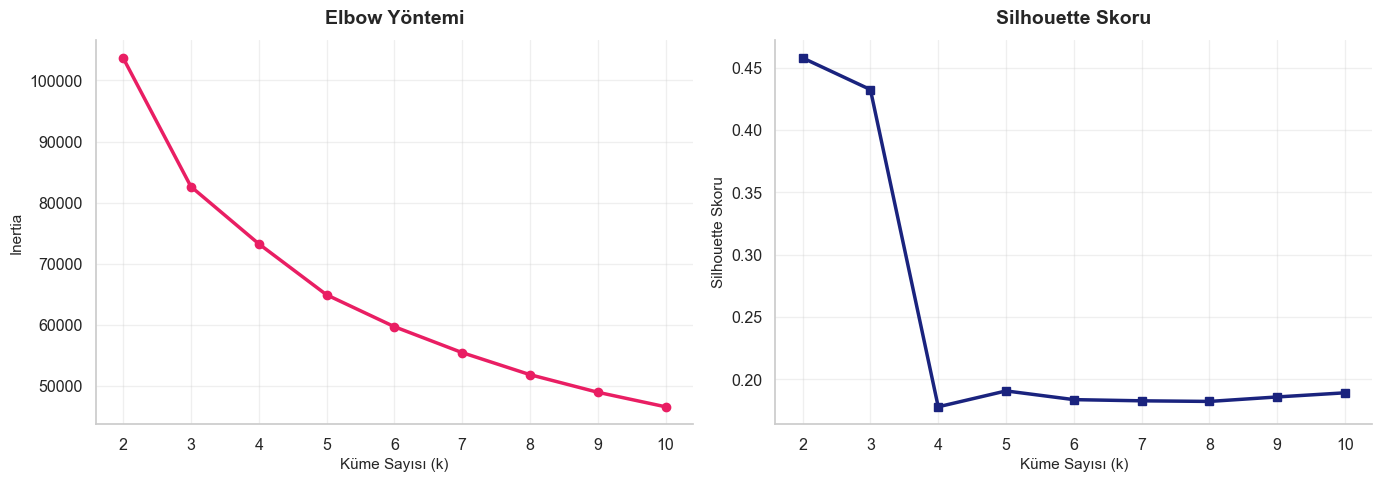

En yüksek Silhouette skoruna göre en iyi k: 2


In [11]:
# === ELBOW VE SILHOUETTE ANALİZİ ===

k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled_df)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, labels))

# Sonuçları tabloya al
k_degerlendirme = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouette_scores
})

display(k_degerlendirme)

# Görselleştir
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_degerlendirme["k"], k_degerlendirme["inertia"],
             marker="o", linewidth=2.5, color=GRATIS_PEMBE)
axes[0].set_title("Elbow Yöntemi", pad=12)
axes[0].set_xlabel("Küme Sayısı (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(k_degerlendirme["k"], k_degerlendirme["silhouette"],
             marker="s", linewidth=2.5, color=GRATIS_LACIVERT)
axes[1].set_title("Silhouette Skoru", pad=12)
axes[1].set_xlabel("Küme Sayısı (k)")
axes[1].set_ylabel("Silhouette Skoru")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k_silhouette = k_degerlendirme.loc[k_degerlendirme["silhouette"].idxmax(), "k"]
print(f"En yüksek Silhouette skoruna göre en iyi k: {best_k_silhouette}")

**Küme Sayısı Kararı:**

Elbow ve Silhouette sonuçları birlikte değerlendirildiğinde, en yüksek Silhouette skoru `k=2` için elde edilmiştir. Ancak `k=2`, ürün davranışlarını yalnızca iki geniş gruba ayırdığı için tüketici açısından yorum gücü sınırlı kalmaktadır.

`k=3` değerinde Silhouette skoru hâlâ yüksek seviyededir ve ürünleri daha anlamlı davranış profillerine ayırma imkânı sunmaktadır. Bu nedenle bu çalışmada **3 küme** kullanılmıştır.

Bu seçimde yalnızca matematiksel skor değil, aynı zamanda kümelerin yorumlanabilirliği de dikkate alınmıştır.

---

## 5) Final K-Means Modeli

Bu bölümde seçilen küme sayısı olan `k=3` ile final K-Means modeli kurulmuştur. Her ürün bir kümeye atanmış ve bu küme etiketi ürün özellikleri tablosuna eklenmiştir.

In [12]:
# === FINAL K-MEANS MODELİ ===

FINAL_K = 3

kmeans_final = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans_final.fit_predict(X_scaled_df)

# Küme etiketlerini ürün özellikleri tablosuna ekle
urun_ozellikleri["cluster"] = cluster_labels

print("Final K-Means modeli kuruldu ✓")
print(f"Küme sayısı: {FINAL_K}")

print("\n=== KÜME DAĞILIMI ===")
cluster_counts = urun_ozellikleri["cluster"].value_counts().sort_index()
cluster_ratios = urun_ozellikleri["cluster"].value_counts(normalize=True).sort_index() * 100

cluster_summary = pd.DataFrame({
    "urun_sayisi": cluster_counts,
    "oran_%": cluster_ratios.round(2)
})

display(cluster_summary)

Final K-Means modeli kuruldu ✓
Küme sayısı: 3

=== KÜME DAĞILIMI ===


,urun_sayisi,oran_%
cluster,,
0,9020,84.87
1,655,6.16
2,953,8.97


In [13]:
# === KÜME PROFİLLERİ ===

cluster_profile = urun_ozellikleri.groupby("cluster").agg(
    urun_sayisi=("urun_id", "count"),
    
    # Fiyat profili
    ortalama_fiyat=("ortalama_fiyat", "mean"),
    medyan_fiyat=("medyan_fiyat", "median"),
    min_fiyat=("min_fiyat", "median"),
    max_fiyat=("max_fiyat", "median"),
    fiyat_araligi_orani=("fiyat_araligi_orani", "mean"),
    fiyat_degisim_orani=("fiyat_degisim_orani", "mean"),
    
    # İndirim profili
    ortalama_indirim=("ortalama_indirim", "mean"),
    max_indirim=("max_indirim", "mean"),
    indirim_std=("indirim_std", "mean"),
    indirimli_gun_orani=("indirimli_gun_orani", "mean"),
    
    # Kampanya profili
    kampanyali_gun_orani=("kampanyali_gun_orani", "mean"),
    farkli_kampanya_sayisi=("farkli_kampanya_sayisi", "mean"),
    
    # Popülerlik
    yorum_sayisi=("yorum_sayisi", "median"),
    begeni_sayi=("begeni_sayi", "median"),
    populerlik_skoru=("populerlik_skoru", "mean"),
    
    # Gözlem
    gozlem_sayisi=("gozlem_sayisi", "mean")
).round(2)

# Oranları yüzde formatında daha okunur hale getirmek için 100 ile çarpılacak kolonlar
yuzde_kolonlari = [
    "fiyat_araligi_orani",
    "fiyat_degisim_orani",
    "indirimli_gun_orani",
    "kampanyali_gun_orani"
]

cluster_profile_display = cluster_profile.copy()

for col in yuzde_kolonlari:
    cluster_profile_display[col] = (cluster_profile_display[col] * 100).round(1)

display(cluster_profile_display)

,urun_sayisi,ortalama_fiyat,medyan_fiyat,min_fiyat,max_fiyat,fiyat_araligi_orani,fiyat_degisim_orani,ortalama_indirim,max_indirim,indirim_std,indirimli_gun_orani,kampanyali_gun_orani,farkli_kampanya_sayisi,yorum_sayisi,begeni_sayi,populerlik_skoru,gozlem_sayisi
cluster,,,,,,,,,,,,,,,,,
0,9020,343.38,224.5,144.0,250.0,47.0,29.0,50.62,67.31,8.84,100.0,27.0,1.01,6.0,1000.0,9.40,11.37
1,655,347.84,199.0,195.0,213.0,7.0,2.0,30.15,32.39,1.63,83.0,0.0,0.00,4.0,1000.0,8.44,8.52
2,953,438.33,120.0,45.0,150.0,88.0,110.0,21.01,66.68,26.59,38.0,23.0,1.00,4.0,1000.0,8.77,11.18


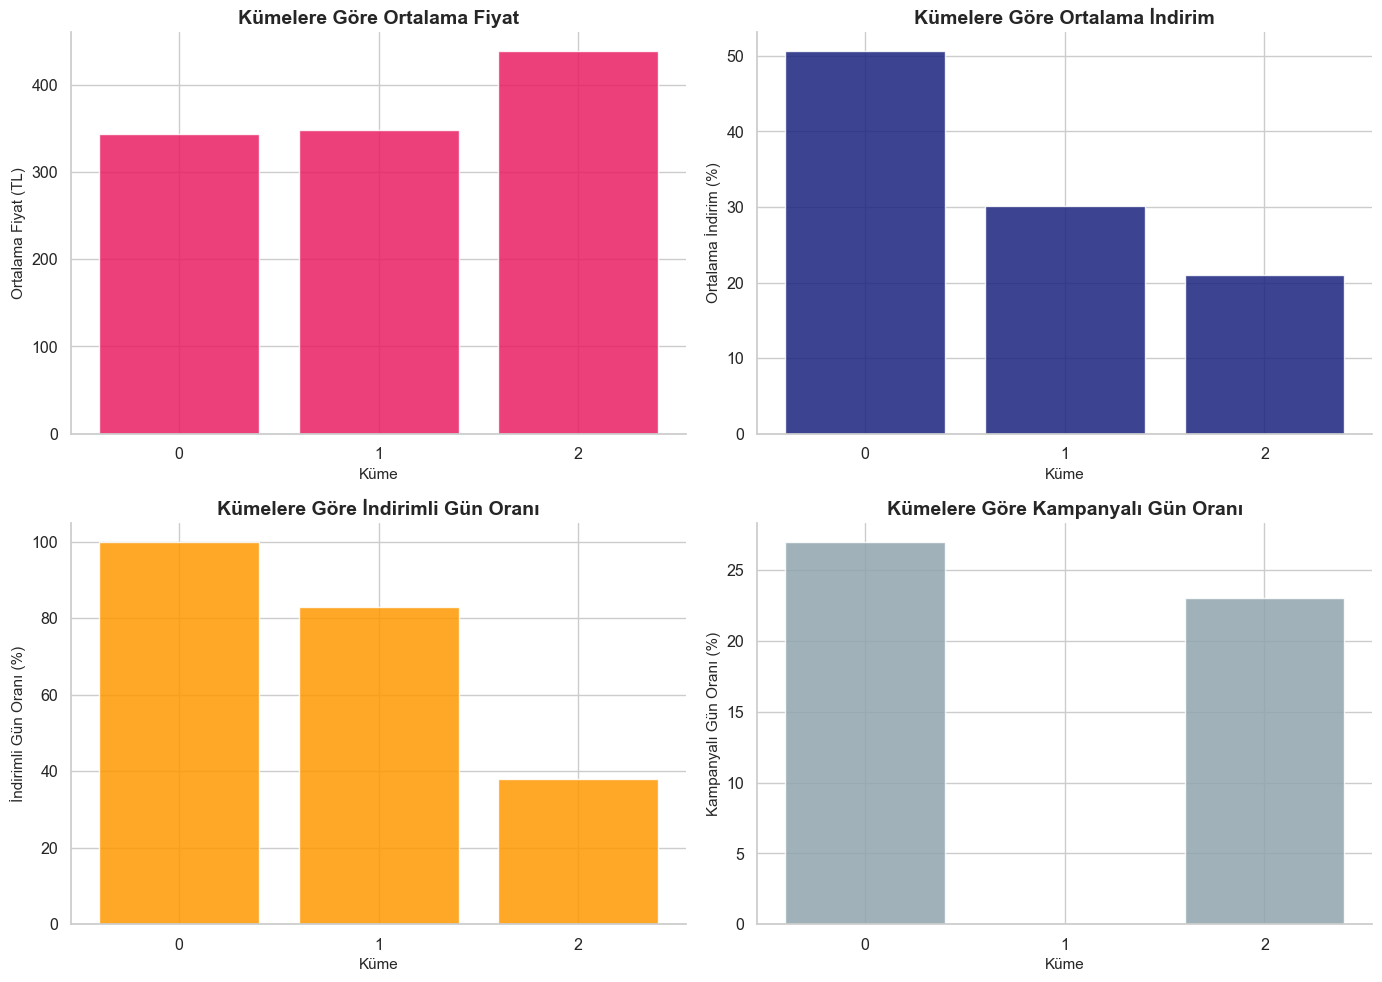

In [14]:
# === KÜME PROFİLLERİNİ GÖRSELLEŞTİRME ===

profile_plot = cluster_profile.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Ortalama fiyat
axes[0, 0].bar(
    profile_plot.index.astype(str),
    profile_plot["ortalama_fiyat"],
    color=GRATIS_PEMBE,
    alpha=0.85
)
axes[0, 0].set_title("Kümelere Göre Ortalama Fiyat")
axes[0, 0].set_xlabel("Küme")
axes[0, 0].set_ylabel("Ortalama Fiyat (TL)")

# 2) Ortalama indirim
axes[0, 1].bar(
    profile_plot.index.astype(str),
    profile_plot["ortalama_indirim"],
    color=GRATIS_LACIVERT,
    alpha=0.85
)
axes[0, 1].set_title("Kümelere Göre Ortalama İndirim")
axes[0, 1].set_xlabel("Küme")
axes[0, 1].set_ylabel("Ortalama İndirim (%)")

# 3) İndirimli gün oranı
axes[1, 0].bar(
    profile_plot.index.astype(str),
    profile_plot["indirimli_gun_orani"] * 100,
    color=ACCENT,
    alpha=0.85
)
axes[1, 0].set_title("Kümelere Göre İndirimli Gün Oranı")
axes[1, 0].set_xlabel("Küme")
axes[1, 0].set_ylabel("İndirimli Gün Oranı (%)")

# 4) Kampanyalı gün oranı
axes[1, 1].bar(
    profile_plot.index.astype(str),
    profile_plot["kampanyali_gun_orani"] * 100,
    color=GRATIS_GRI,
    alpha=0.85
)
axes[1, 1].set_title("Kümelere Göre Kampanyalı Gün Oranı")
axes[1, 1].set_xlabel("Küme")
axes[1, 1].set_ylabel("Kampanyalı Gün Oranı (%)")

plt.tight_layout()
plt.show()

---

## 6) PCA ile Küme Görselleştirme

K-Means modeli 12 sayısal değişken üzerinden kurulmuştur. Bu çok boyutlu yapıyı iki boyutta görselleştirebilmek için PCA uygulanmıştır.

PCA, ürünlerin temel varyasyonunu iki ana bileşene indirger ve kümelerin birbirinden ne kadar ayrıştığını görsel olarak incelememizi sağlar.

PC1 açıklanan varyans: %26.55
PC2 açıklanan varyans: %24.35
Toplam açıklanan varyans: %50.90


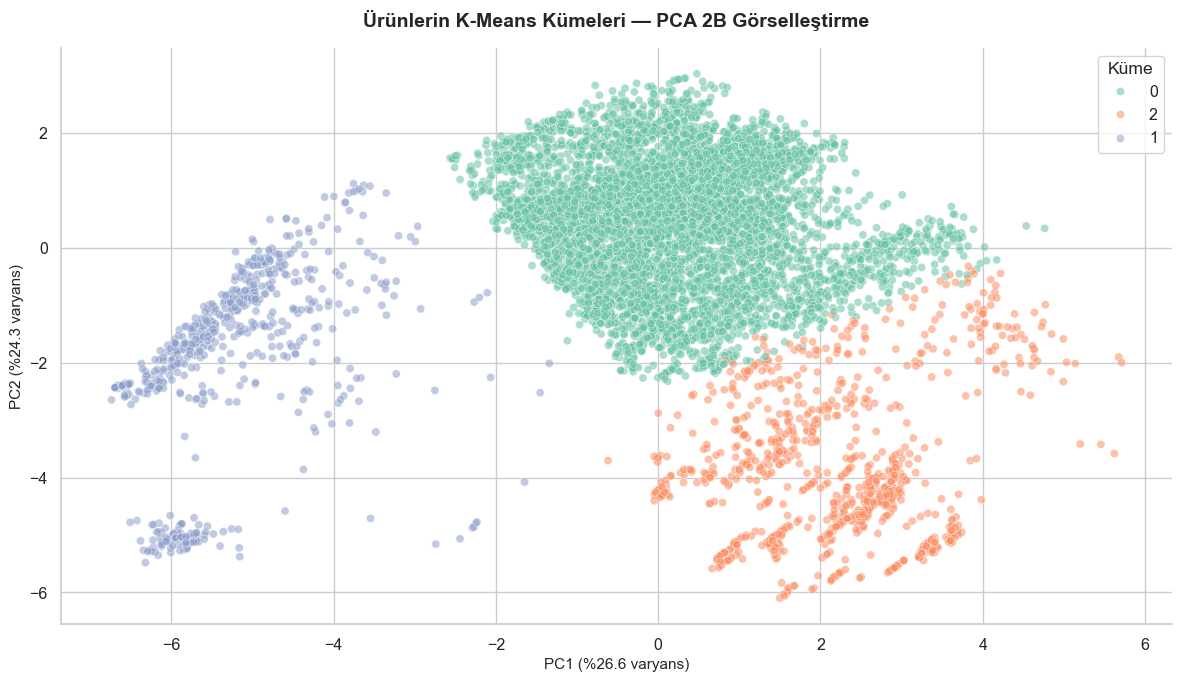

In [15]:
# === PCA İLE 2 BOYUTLU GÖRSELLEŞTİRME ===

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": urun_ozellikleri["cluster"].astype(str),
    "kategori": urun_ozellikleri["kategori"],
    "marka": urun_ozellikleri["marka"],
    "isim": urun_ozellikleri["isim"]
})

explained_var = pca.explained_variance_ratio_ * 100

print(f"PC1 açıklanan varyans: %{explained_var[0]:.2f}")
print(f"PC2 açıklanan varyans: %{explained_var[1]:.2f}")
print(f"Toplam açıklanan varyans: %{explained_var.sum():.2f}")

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    alpha=0.55,
    s=35,
    palette="Set2"
)

plt.title("Ürünlerin K-Means Kümeleri — PCA 2B Görselleştirme", pad=15)
plt.xlabel(f"PC1 (%{explained_var[0]:.1f} varyans)")
plt.ylabel(f"PC2 (%{explained_var[1]:.1f} varyans)")
plt.legend(title="Küme")
plt.tight_layout()
plt.show()

**Küme Profillerinin Yorumlanması**

K-Means sonucunda ürünler üç ana fiyat ve indirim davranışı profiline ayrılmıştır.

| Küme | Küme Adı | Ürün Sayısı | Genel Karakter |
|---:|---|---:|---|
| 0 | **Sürekli İndirimli Ana Katalog Ürünleri** | 9020 | Neredeyse her zaman indirimli, ortalama indirim yüksek |
| 1 | **Stabil ve Düşük Kampanyalı Ürünler** | 655 | Fiyat ve indirim oynaklığı düşük, kampanya etkisi sınırlı |
| 2 | **Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri** | 953 | Her zaman indirimli değil, fakat dönemsel olarak yüksek indirim alabiliyor |

### Küme 0 — Sürekli İndirimli Ana Katalog Ürünleri

Bu küme veri setinin büyük çoğunluğunu oluşturmaktadır. Ortalama indirim oranı yaklaşık **%50**, indirimli gün oranı ise **%100** seviyesindedir. Bu durum, bu ürünlerde indirim görünümünün neredeyse sürekli olduğunu göstermektedir.

Tüketici açısından bu kümede yalnızca “indirimde mi?” sorusu yeterli değildir. Çünkü ürünler zaten çoğu zaman indirimlidir. Bu nedenle bu kümede daha anlamlı soru şudur:

> Ürün bugün kendi geçmiş fiyatına göre gerçekten avantajlı mı?

### Küme 1 — Stabil ve Düşük Kampanyalı Ürünler

Bu kümede fiyat ve indirim oynaklığı oldukça düşüktür. Ortalama indirim oranı diğer kümelere göre daha sınırlıdır ve kampanyalı gün oranı neredeyse sıfırdır.

Bu ürünler tüketici açısından daha stabil fiyatlı ürünlerdir. Bu nedenle bekleyerek çok büyük fiyat avantajı yakalama olasılığı sınırlı olabilir.

### Küme 2 — Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri

Bu kümede ortalama indirim düşük görünmesine rağmen maksimum indirim oranı yüksektir. Ayrıca fiyat değişim oranı ve indirim oynaklığı diğer kümelere göre belirgin şekilde fazladır.

Bu durum, bu ürünlerin her zaman indirimde olmadığını; ancak belirli dönemlerde güçlü fiyat avantajı sunabildiğini göstermektedir.

Tüketici açısından en dikkat çekici küme budur. Çünkü doğru zamanda takip edildiğinde yüksek fırsat potansiyeli taşıyabilir.

In [16]:
# === KÜME İSİMLERİNİ EKLE ===

cluster_name_map = {
    0: "Sürekli İndirimli Ana Katalog Ürünleri",
    1: "Stabil ve Düşük Kampanyalı Ürünler",
    2: "Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri"
}

urun_ozellikleri["cluster_adi"] = urun_ozellikleri["cluster"].map(cluster_name_map)

print("Küme isimleri eklendi ✓")

display(
    urun_ozellikleri[
        [
            "urun_id",
            "isim",
            "marka",
            "kategori",
            "cluster",
            "cluster_adi",
            "ortalama_fiyat",
            "ortalama_indirim",
            "indirimli_gun_orani",
            "kampanyali_gun_orani"
        ]
    ].head(10)
)

Küme isimleri eklendi ✓


,urun_id,isim,marka,kategori,cluster,cluster_adi,ortalama_fiyat,ortalama_indirim,indirimli_gun_orani,kampanyali_gun_orani
0,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,0,Sürekli İndirimli Ana Katalog Ürünleri,335.133333,25.693333,1.000000,0.133333
1,10000236,Kalyon Tırnak Besleyici,Kalyon,Makyaj,2,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,249.550000,6.010000,0.100000,0.100000
2,10000237,Kalyon Oje Kurutucu Sprey,Kalyon,Makyaj,2,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,300.950000,13.020000,0.200000,0.200000
3,10000238,Kalyon Oje Koruyucu,Kalyon,Makyaj,1,Stabil ve Düşük Kampanyalı Ürünler,265.500000,0.000000,0.000000,0.000000
4,10000240,Kalyon Bakım Yağı,Kalyon,Makyaj,2,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,245.562500,7.512500,0.125000,0.125000
5,10000241,Kalyon Oje Çözücü,Kalyon,Makyaj,2,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,102.909091,17.336364,0.272727,0.272727
6,10000242,Kalyon Tırnak Eti Temizleyici,Kalyon,Makyaj,2,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,251.000000,5.463636,0.090909,0.090909
7,10000349,Sebamed Pişik Önleyici Krem 100 ml,Sebamed,Anne & Bebek,0,Sürekli İndirimli Ana Katalog Ürünleri,307.615385,43.630769,1.000000,0.153846
8,10000368,Flormar Nail Enamel Yoğun Pigmentli Oje 352 Bl...,Flormar,Makyaj,2,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,71.000000,29.000000,0.500000,0.300000
9,10000369,Flormar Nail Enamel Yoğun Pigmentli Oje 385 Re...,Flormar,Makyaj,2,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,74.285714,25.714286,0.428571,0.285714


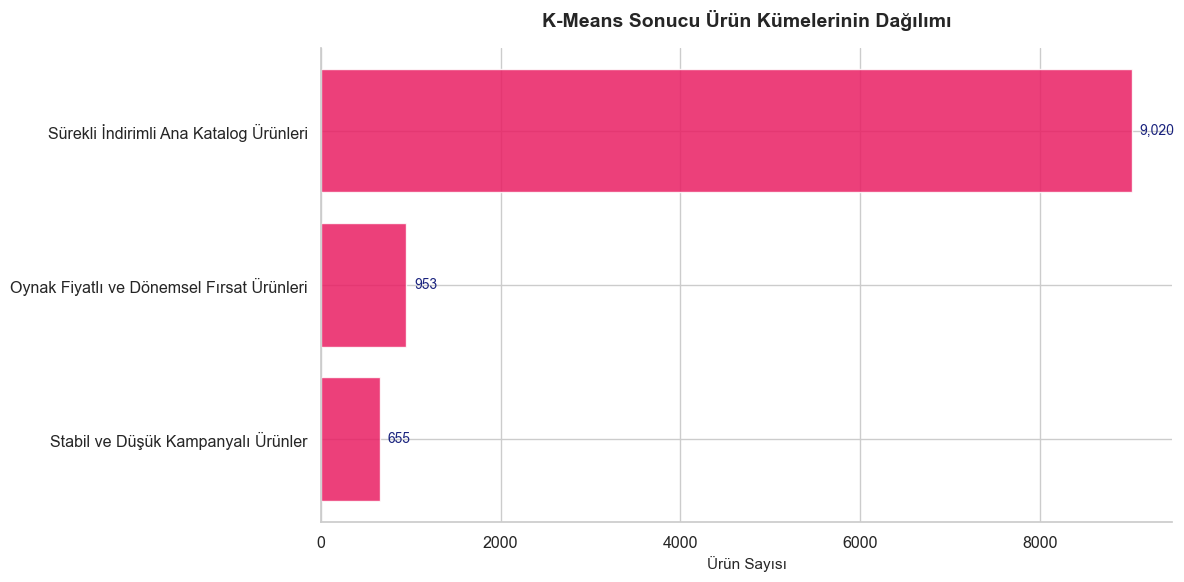

In [17]:
# === KÜME DAĞILIMI GRAFİĞİ ===

cluster_counts_named = (
    urun_ozellikleri["cluster_adi"]
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    cluster_counts_named.index,
    cluster_counts_named.values,
    color=GRATIS_PEMBE,
    alpha=0.85,
    edgecolor="white"
)

ax.set_title("K-Means Sonucu Ürün Kümelerinin Dağılımı", pad=15)
ax.set_xlabel("Ürün Sayısı")
ax.set_ylabel("")

for bar, val in zip(bars, cluster_counts_named.values):
    ax.text(
        val + max(cluster_counts_named.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        fontsize=10,
        color=GRATIS_LACIVERT
    )

plt.tight_layout()
plt.show()

---

## 7) Kümelerin Kategori Dağılımı

Kümelerin yalnızca sayısal olarak değil, kategori yapısı bakımından da nasıl farklılaştığını incelemek gerekir. Bu bölümde her kümedeki baskın kategoriler analiz edilmiştir.

kategori,Anne & Bebek,Cilt Bakım,Duş & Banyo,Elektrikli Ürünler,Erkek Bakım,Ev & Yaşam,Güneş Ürünleri,Hijyen & Bakım,Kişisel Bakım,Makyaj,Moda & Aksesuar,Parfüm & Deodorant,Saç Bakım,Süpermarket
cluster_adi,,,,,,,,,,,,,,
Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,1.4,8.7,0.4,0.0,4.0,0.9,0.7,9.3,3.3,56.5,1.8,5.4,3.8,3.9
Stabil ve Düşük Kampanyalı Ürünler,5.5,5.5,11.6,1.1,8.1,3.2,1.5,4.7,6.9,3.5,12.8,6.4,18.8,10.4
Sürekli İndirimli Ana Katalog Ürünleri,1.6,16.6,3.3,0.5,4.2,0.7,2.1,5.9,8.5,34.4,2.8,5.1,13.5,0.8


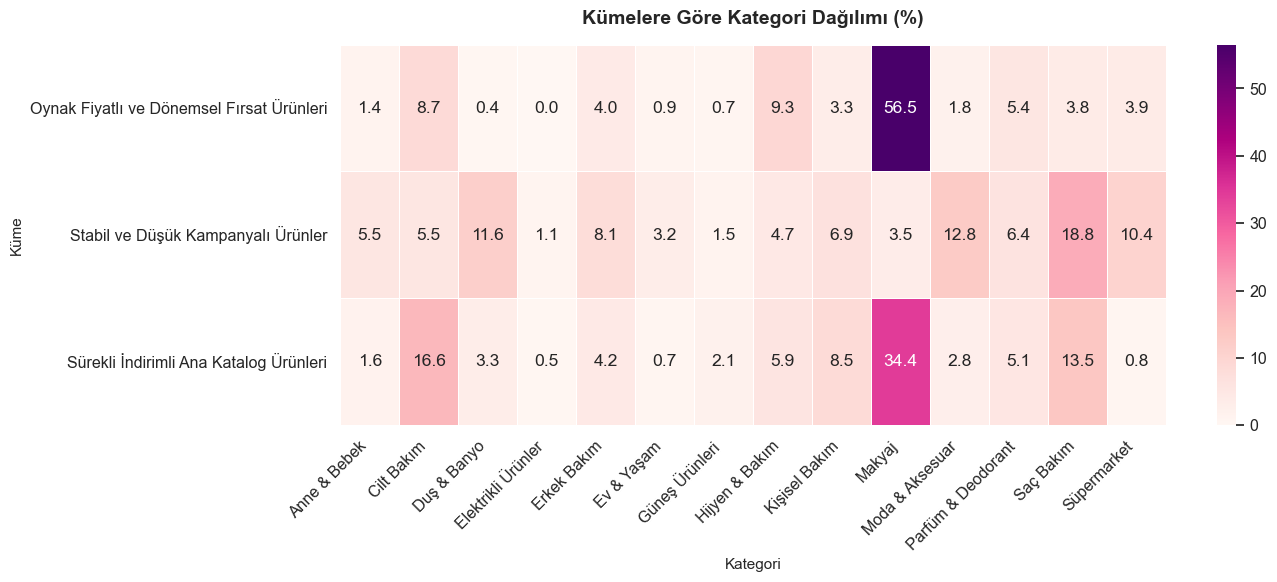

In [18]:
# === KÜME × KATEGORİ DAĞILIMI ===

cluster_category = pd.crosstab(
    urun_ozellikleri["cluster_adi"],
    urun_ozellikleri["kategori"],
    normalize="index"
) * 100

# En okunur olması için değerleri yuvarla
cluster_category_rounded = cluster_category.round(1)

display(cluster_category_rounded)

plt.figure(figsize=(14, 6))

sns.heatmap(
    cluster_category_rounded,
    annot=True,
    fmt=".1f",
    cmap="RdPu",
    linewidths=0.5
)

plt.title("Kümelere Göre Kategori Dağılımı (%)", pad=15)
plt.xlabel("Kategori")
plt.ylabel("Küme")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
# === HER KÜMEDEN ÖRNEK ÜRÜNLER ===

for cluster_name in urun_ozellikleri["cluster_adi"].unique():
    print("\n" + "=" * 100)
    print(cluster_name)
    print("=" * 100)
    
    ornekler = (
        urun_ozellikleri[urun_ozellikleri["cluster_adi"] == cluster_name]
        .sort_values("populerlik_skoru", ascending=False)
        .head(8)
    )
    
    display(
        ornekler[
            [
                "urun_id",
                "isim",
                "marka",
                "kategori",
                "ortalama_fiyat",
                "ortalama_indirim",
                "max_indirim",
                "indirimli_gun_orani",
                "kampanyali_gun_orani",
                "populerlik_skoru"
            ]
        ]
    )


Sürekli İndirimli Ana Katalog Ürünleri


,urun_id,isim,marka,kategori,ortalama_fiyat,ortalama_indirim,max_indirim,indirimli_gun_orani,kampanyali_gun_orani,populerlik_skoru
6360,10213273,Beaulis Finish It Transparan Sabitleyici Pudra...,Beaulis,Makyaj,117.000000,55.014286,70.1,1.000000,0.357143,18.973053
1333,10128829,Beaulis Print It Dudak Kalemi 104 Caramel,Beaulis,Makyaj,56.227273,48.254545,75.0,1.000000,0.454545,18.964033
1370,10131344,Beaulis Fake It Maskara 100 Black,Beaulis,Makyaj,103.576923,61.615385,75.0,0.923077,0.384615,18.635186
8592,10317170,LYKD Makyaj Sabitleyici Sprey Dewy,LYKD,Makyaj,155.916667,60.908333,75.1,1.000000,0.916667,18.571002
1018,10070582,wet n wild MegaGlo Aydınlatıcı Pudra Blossom Glow,wet,Makyaj,301.000000,59.508333,75.0,1.000000,0.416667,18.525229
1897,10196575,Beaulis Close It Likit Kapatıcı 130 Porcelain,Beaulis,Makyaj,86.733333,63.740000,75.1,1.000000,0.400000,18.501116
1371,10131345,Beaulis Curl It Maskara Hacimli ve Kıvrık Kirp...,Beaulis,Makyaj,89.607143,66.785714,75.0,1.000000,0.357143,18.293084
8230,10223323,Beaulis Glide It Eyeliner 100 Black,Beaulis,Makyaj,105.500000,55.400000,70.1,1.000000,0.384615,18.163421



Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri


,urun_id,isim,marka,kategori,ortalama_fiyat,ortalama_indirim,max_indirim,indirimli_gun_orani,kampanyali_gun_orani,populerlik_skoru
10244,11001078,Emily Long Lasting Lip Pencil Dudak Kalemi 203,Emily,Makyaj,97.307692,15.384615,70.0,0.230769,0.230769,18.311321
9164,10524242,Beaulis Drop It pH Değişimli Dudak Parlatıcısı...,Beaulis,Makyaj,130.678571,47.250000,75.1,0.785714,0.428571,15.917733
2728,10202462,Emily Long Lasting Lip Pencil Dudak Kalemi 217,Emily,Makyaj,98.192308,14.615385,70.0,0.230769,0.230769,15.466319
2028,10198965,Emily Long Lasting Lip Pencil Dudak Kalemi 222,Emily,Makyaj,96.791667,15.833333,70.0,0.250000,0.250000,15.297379
10245,11001080,Emily Long Lasting Lip Pencil Dudak Kalemi 205,Emily,Makyaj,95.136364,17.272727,70.0,0.272727,0.272727,14.856193
1,10000236,Kalyon Tırnak Besleyici,Kalyon,Makyaj,249.550000,6.010000,60.1,0.100000,0.100000,14.816172
10248,11001083,Emily Long Lasting Lip Pencil Dudak Kalemi 208,Emily,Makyaj,100.050000,13.000000,70.0,0.200000,0.200000,14.564164
3288,10204329,rom&nd Better Than Palette Far Paleti 07 Berry...,rom&nd,Makyaj,1142.800000,48.000000,70.0,0.800000,0.400000,14.343846



Stabil ve Düşük Kampanyalı Ürünler


,urun_id,isim,marka,kategori,ortalama_fiyat,ortalama_indirim,max_indirim,indirimli_gun_orani,kampanyali_gun_orani,populerlik_skoru
1532,10153610,Morfose Milk Therapy Saç Köpüğü 200 ml,Morfose,Saç Bakım,181.727273,55.318182,56.5,1.0,0.0,17.111399
4143,10208183,Flormar Sheer Up Nemlendirici Etkili Yarı Tran...,Flormar,Makyaj,435.000000,50.000000,50.0,1.0,0.0,16.497373
106,10008862,Blistex MedPlus Stick SPF 15 - Kuruyan ve Çatl...,Blistex,Cilt Bakım,185.000000,30.200000,30.2,1.0,0.0,15.324494
9128,10508348,Urban Care Summer Glow Aşamalı Renk Açıcı Spre...,Urban,Saç Bakım,286.500000,52.275000,66.8,1.0,0.0,14.238232
516,10029680,Dalin Kolay Tarama Spreyi 200 ml,Dalin,Anne & Bebek,165.666667,48.533333,50.6,1.0,0.0,14.204902
10345,12000671,Taft Curl & Flex Saç Köpüğü 150 ml,Taft,Saç Bakım,220.428571,42.928571,59.6,1.0,0.0,14.192632
9576,10665473,Nascita Pro Üç Boyutlu Oval Saç Fırçası 02,Nascita,Saç Bakım,239.000000,30.300000,30.3,1.0,0.0,14.077925
2536,10201499,Nascita Pro Açılı Allık Makyaj Fırçası 253,Nascita,Kişisel Bakım,267.000000,40.100000,40.1,1.0,0.0,13.884151


---

## 8) Küme Sonuçlarının Kaydedilmesi

Küme etiketleri ve küme adları ürün özellikleri tablosuna eklenmiş ve sonraki analizlerde kullanılmak üzere kaydedilmiştir.

In [20]:
# === KÜME SONUÇLARINI KAYDET ===

CLUSTER_PATH = PROCESSED_DIR / "urun_kumeleri.csv"

urun_ozellikleri.to_csv(CLUSTER_PATH, index=False, encoding="utf-8-sig")

print("Küme sonuçları başarıyla kaydedildi ✓")
print(f"Dosya yolu: {CLUSTER_PATH}")

# Doğrulama
urun_kumeleri_check = pd.read_csv(CLUSTER_PATH, encoding="utf-8-sig")

print("\n=== KAYIT DOĞRULAMA ===")
print(f"Okunan satır sayısı: {len(urun_kumeleri_check):,}")
print(f"Orijinal satır sayısı: {len(urun_ozellikleri):,}")
print(f"Sütunlar eşleşiyor mu?: {list(urun_kumeleri_check.columns) == list(urun_ozellikleri.columns)}")

Küme sonuçları başarıyla kaydedildi ✓
Dosya yolu: ..\data\processed\urun_kumeleri.csv

=== KAYIT DOĞRULAMA ===
Okunan satır sayısı: 10,628
Orijinal satır sayısı: 10,628
Sütunlar eşleşiyor mu?: True


---

## Notebook Özeti

Bu notebook kapsamında temiz ürün-gün verisi ürün bazlı bir analiz tablosuna dönüştürülmüş ve ürünler fiyat/indirim davranışlarına göre kümelenmiştir.

### Yapılan İşlemler

1. `gratis_clean.csv` dosyası okundu.
2. Her ürün için fiyat, indirim, kampanya, popülerlik ve gözlem özellikleri hesaplandı.
3. Ürün bazlı özellik tablosu oluşturuldu.
4. K-Means için sayısal değişkenler seçildi.
5. Değişkenler uç değerlere karşı kırpıldı ve standartlaştırıldı.
6. Elbow ve Silhouette yöntemleriyle küme sayısı değerlendirildi.
7. Yorumlanabilirlik ve Silhouette skoru birlikte değerlendirilerek **k=3** seçildi.
8. Final K-Means modeli kuruldu.
9. Ürünler üç davranış profiline ayrıldı:

| Küme | Küme Adı | Genel Yorum |
|---:|---|---|
| 0 | Sürekli İndirimli Ana Katalog Ürünleri | Neredeyse her zaman indirimli, yüksek ortalama indirimli ürünler |
| 1 | Stabil ve Düşük Kampanyalı Ürünler | Fiyat ve indirim hareketi sınırlı, kampanya etkisi düşük ürünler |
| 2 | Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri | Zaman zaman yüksek indirim sunan, fiyat hareketi güçlü ürünler |

### Sonraki Adım

Bir sonraki aşamada bu küme bilgileri kullanılarak tüketiciye yönelik **fırsat skoru** ve ürün değerlendirme sistemi oluşturulabilir.